# Day 6: Ensemble Methods

**Dataset:** Titanic cleaned (from Day 2)
**Target:** `survived` (binary)
**Goal:** Random Forest, XGBoost, LightGBM vs single Decision Tree

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('../data/titanic_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (891, 19)


In [4]:
# 1. PREPARE FEATURES & TARGET (same as Day 5)
numeric_features = ['age', 'sibsp', 'parch', 'family_size', 'fare_per_person', 'pclass', 'is_alone']
cat_features = ['sex', 'embarked', 'deck', 'who', 'age_bin']

df_encoded = df.copy()
for col in cat_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))

encoded_features = [c + '_encoded' for c in cat_features]
all_features = numeric_features + encoded_features

X = df_encoded[all_features]
y = df_encoded['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 12), Test: (179, 12)


In [5]:
# 2. RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Died', 'Survived']))

=== Random Forest ===
Accuracy:  0.7765
ROC-AUC:   0.8495
              precision    recall  f1-score   support

        Died       0.84      0.79      0.81       110
    Survived       0.69      0.75      0.72        69

    accuracy                           0.78       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [6]:
# 3. XGBOOST
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Died', 'Survived']))

=== XGBoost ===
Accuracy:  0.8045
ROC-AUC:   0.8246
              precision    recall  f1-score   support

        Died       0.84      0.84      0.84       110
    Survived       0.74      0.75      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



In [7]:
# 4. LIGHTGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_clf.fit(X_train, y_train)

y_pred_lgb = lgb_clf.predict(X_test)
y_proba_lgb = lgb_clf.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb, target_names=['Died', 'Survived']))

=== LightGBM ===
Accuracy:  0.7933
ROC-AUC:   0.8196
              precision    recall  f1-score   support

        Died       0.83      0.84      0.83       110
    Survived       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



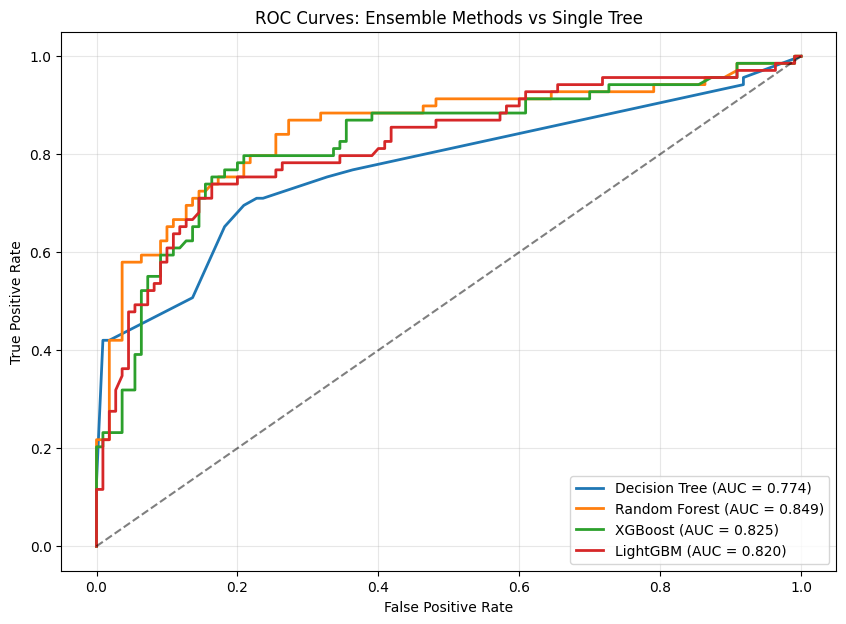

In [8]:
# 5. COMPARISON: ROC CURVES
from sklearn.tree import DecisionTreeClassifier

# Reference: single Decision Tree from Day 5
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

models = {
    'Decision Tree': y_proba_dt,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'LightGBM': y_proba_lgb
}

plt.figure(figsize=(10, 7))
for name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Ensemble Methods vs Single Tree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

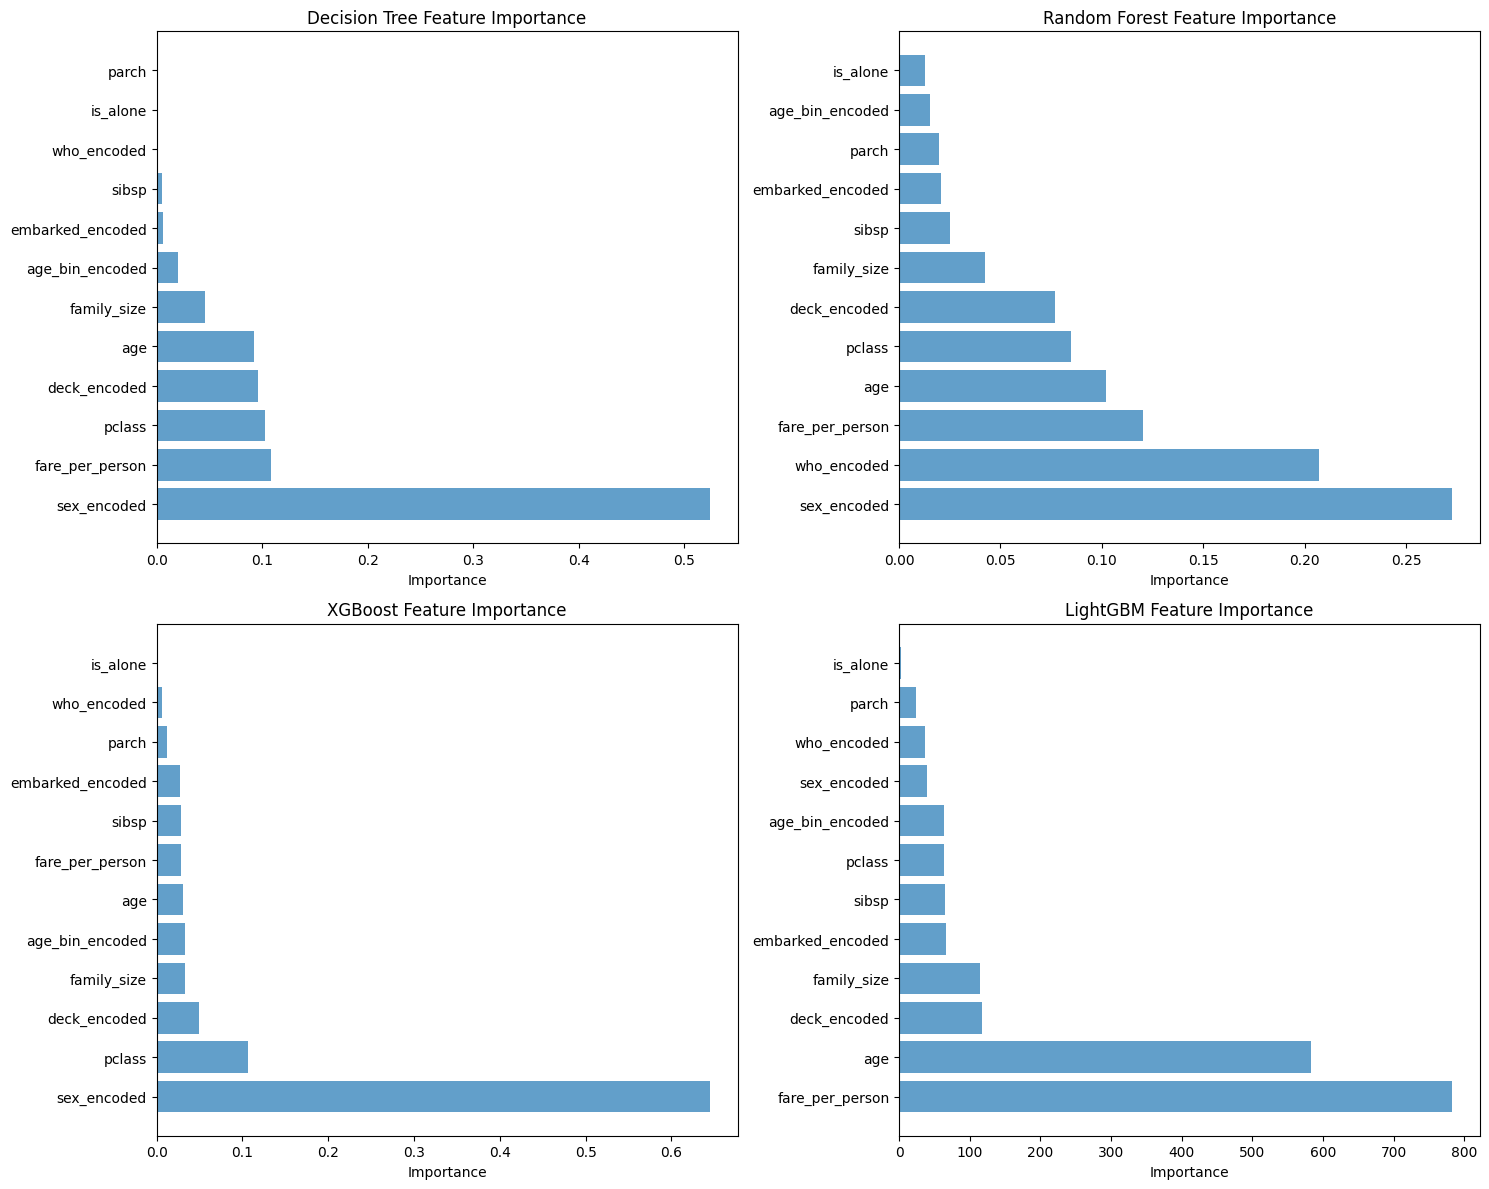

In [9]:
# 6. FEATURE IMPORTANCE COMPARISON
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

importances = {
    'Decision Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb_clf.feature_importances_,
    'LightGBM': lgb_clf.feature_importances_
}

for i, (name, imp) in enumerate(importances.items()):
    imp_df = pd.DataFrame({'feature': all_features, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=True)
    axes[i].barh(range(len(imp_df)), imp_df['importance'], alpha=0.7)
    axes[i].set_yticks(range(len(imp_df)))
    axes[i].set_yticklabels(imp_df['feature'])
    axes[i].set_xlabel('Importance')
    axes[i].set_title(f'{name} Feature Importance')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# 7. HYPERPARAMETER TUNING: XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    xgb_base, param_grid_xgb, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train)

print(f"Best XGBoost params: {grid_xgb.best_params_}")
print(f"Best XGBoost CV ROC-AUC: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_best_xgb):.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost CV ROC-AUC: 0.8763
Test ROC-AUC: 0.8375


In [12]:
# 8. HYPERPARAMETER TUNING: LightGBM
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

grid_lgb = GridSearchCV(
    lgb_base, param_grid_lgb, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_lgb.fit(X_train, y_train)

print(f"Best LightGBM params: {grid_lgb.best_params_}")
print(f"Best LightGBM CV ROC-AUC: {grid_lgb.best_score_:.4f}")

best_lgb = grid_lgb.best_estimator_
y_proba_best_lgb = best_lgb.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_best_lgb):.4f}")

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best LightGBM CV ROC-AUC: 0.8781
Test ROC-AUC: 0.8385


## Summary Notes

- Best ensemble (test ROC-AUC): 
- Boosting vs bagging performance: 
- Key hyperparameters from tuning: 
- Why gradient boosting beats single tree: 